### RQ3 — Which emotions are systematically difficult for VLLMs to recognize, and what factors contribute to these difficulties?

Let's analyse in a overall setting first:

In [2]:
import pandas as pd
from datasets import load_dataset
import os
from dotenv import load_dotenv
load_dotenv()
hf_token = os.getenv("HF_TOKEN")
ds = load_dataset(
        f"Emotion-Aware-AI-Assistant/all_models_results_v1",
        split="train",
        token=hf_token
    )
df = pd.DataFrame(ds)

c:\Users\FernandaBufon\miniconda3\envs\nlp\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
df

,model_name,output_method,accuracy,macro_f1,macro_precision,macro_recall,weighted_f1,weighted_precision,weighted_recall,confusion_matrix_json,...,wrong_format,emotion_refused,emotion_not_listed,total_time,total_time_hours,mean_time,response_time_std,response_time_mode,tie_counts_json,method
0,deepface,None,0.510464,0.327210,0.399528,0.345444,0.501869,0.549049,0.510464,"{""anger"":{""anger"":375,""disgust"":232,""fear"":44,...",...,0,0,0,322.92,0.089700,0.021052,0.012043,0.02,,None
1,llava:13b,discrete,0.475129,0.426525,0.542604,0.390312,0.526043,0.694171,0.475129,"{""anger"":{""anger"":315,""disgust"":43,""fear"":18,""...",...,2187,71,0,32011.67,8.892131,2.086946,0.505803,1.70,,simple
2,minicpm-v:8b,discrete,0.303084,0.297540,0.426439,0.263177,0.384475,0.606171,0.303084,"{""anger"":{""anger"":441,""disgust"":220,""fear"":61,...",...,3497,2943,0,15258.60,4.238500,0.994758,0.369856,0.80,,simple
3,llava:7b,discrete,0.531456,0.440516,0.551434,0.412749,0.564529,0.691856,0.531456,"{""anger"":{""anger"":319,""disgust"":58,""fear"":12,""...",...,1236,19,0,9820.74,2.727983,0.640246,0.161269,0.59,,simple
4,llava-phi3:3.8b,discrete,0.380142,0.316164,0.373686,0.282804,0.444100,0.550578,0.380142,"{""anger"":{""anger"":264,""disgust"":110,""fear"":29,...",...,3323,585,0,6702.26,1.861739,0.436942,0.148640,0.40,,simple
5,qwen3-vl:30b-a3b-instruct,discrete,0.756503,0.627703,0.642684,0.648975,0.756598,0.783284,0.756503,"{""anger"":{""anger"":665,""disgust"":206,""fear"":44,...",...,0,0,0,14540.64,4.039067,0.947952,0.163470,0.89,,simple
6,qwen3-vl:8b-instruct,discrete,0.758980,0.598045,0.619720,0.638043,0.752112,0.769304,0.758980,"{""anger"":{""anger"":730,""disgust"":308,""fear"":61,...",...,1,0,0,14509.93,4.030536,0.945950,0.156328,0.88,,simple
7,qwen3-vl:4b-instruct,discrete,0.722994,0.581013,0.588419,0.596567,0.721535,0.737512,0.722994,"{""anger"":{""anger"":713,""disgust"":263,""fear"":69,...",...,6,1,0,9687.12,2.690867,0.631535,0.977483,0.51,,simple
8,qwen3-vl:2b-instruct,discrete,0.652780,0.520233,0.569684,0.541817,0.653459,0.708081,0.652780,"{""anger"":{""anger"":615,""disgust"":109,""fear"":51,...",...,26,24,0,6311.89,1.753303,0.411493,0.587138,0.37,,simple
9,qwen3-vl:32b-instruct,discrete,0.723059,0.583612,0.600459,0.627563,0.730515,0.767407,0.723059,"{""anger"":{""anger"":780,""disgust"":398,""fear"":87,...",...,0,0,0,43492.23,12.081175,2.835402,0.489611,2.53,,simple


All data were from discrete and simple. 

In [4]:
df_discrete = df[(df['output_method'] == 'discrete') & (df['method'] == "simple")]
df_discrete

,model_name,output_method,accuracy,macro_f1,macro_precision,macro_recall,weighted_f1,weighted_precision,weighted_recall,confusion_matrix_json,...,wrong_format,emotion_refused,emotion_not_listed,total_time,total_time_hours,mean_time,response_time_std,response_time_mode,tie_counts_json,method
1,llava:13b,discrete,0.475129,0.426525,0.542604,0.390312,0.526043,0.694171,0.475129,"{""anger"":{""anger"":315,""disgust"":43,""fear"":18,""...",...,2187,71,0,32011.67,8.892131,2.086946,0.505803,1.70,,simple
2,minicpm-v:8b,discrete,0.303084,0.297540,0.426439,0.263177,0.384475,0.606171,0.303084,"{""anger"":{""anger"":441,""disgust"":220,""fear"":61,...",...,3497,2943,0,15258.60,4.238500,0.994758,0.369856,0.80,,simple
3,llava:7b,discrete,0.531456,0.440516,0.551434,0.412749,0.564529,0.691856,0.531456,"{""anger"":{""anger"":319,""disgust"":58,""fear"":12,""...",...,1236,19,0,9820.74,2.727983,0.640246,0.161269,0.59,,simple
4,llava-phi3:3.8b,discrete,0.380142,0.316164,0.373686,0.282804,0.444100,0.550578,0.380142,"{""anger"":{""anger"":264,""disgust"":110,""fear"":29,...",...,3323,585,0,6702.26,1.861739,0.436942,0.148640,0.40,,simple
5,qwen3-vl:30b-a3b-instruct,discrete,0.756503,0.627703,0.642684,0.648975,0.756598,0.783284,0.756503,"{""anger"":{""anger"":665,""disgust"":206,""fear"":44,...",...,0,0,0,14540.64,4.039067,0.947952,0.163470,0.89,,simple
6,qwen3-vl:8b-instruct,discrete,0.758980,0.598045,0.619720,0.638043,0.752112,0.769304,0.758980,"{""anger"":{""anger"":730,""disgust"":308,""fear"":61,...",...,1,0,0,14509.93,4.030536,0.945950,0.156328,0.88,,simple
7,qwen3-vl:4b-instruct,discrete,0.722994,0.581013,0.588419,0.596567,0.721535,0.737512,0.722994,"{""anger"":{""anger"":713,""disgust"":263,""fear"":69,...",...,6,1,0,9687.12,2.690867,0.631535,0.977483,0.51,,simple
8,qwen3-vl:2b-instruct,discrete,0.652780,0.520233,0.569684,0.541817,0.653459,0.708081,0.652780,"{""anger"":{""anger"":615,""disgust"":109,""fear"":51,...",...,26,24,0,6311.89,1.753303,0.411493,0.587138,0.37,,simple
9,qwen3-vl:32b-instruct,discrete,0.723059,0.583612,0.600459,0.627563,0.730515,0.767407,0.723059,"{""anger"":{""anger"":780,""disgust"":398,""fear"":87,...",...,0,0,0,43492.23,12.081175,2.835402,0.489611,2.53,,simple
10,llava-llama3:8b,discrete,0.381250,0.321844,0.454792,0.271171,0.462261,0.626050,0.381250,"{""anger"":{""anger"":180,""disgust"":44,""fear"":16,""...",...,4987,294,0,15725.58,4.368217,1.025202,0.680322,0.27,,simple


In [5]:
df_discrete.columns

Index(['model_name', 'output_method', 'accuracy', 'macro_f1',
       'macro_precision', 'macro_recall', 'weighted_f1', 'weighted_precision',
       'weighted_recall', 'confusion_matrix_json', 'invalid_counts_json',
       'f1_anger', 'f1_disgust', 'f1_fear', 'f1_happiness', 'f1_neutral',
       'f1_sadness', 'f1_surprise', 'precision_anger', 'precision_disgust',
       'precision_fear', 'precision_happiness', 'precision_neutral',
       'precision_sadness', 'precision_surprise', 'recall_anger',
       'recall_disgust', 'recall_fear', 'recall_happiness', 'recall_neutral',
       'recall_sadness', 'recall_surprise', 'wrong_format', 'emotion_refused',
       'emotion_not_listed', 'total_time', 'total_time_hours', 'mean_time',
       'response_time_std', 'response_time_mode', 'tie_counts_json', 'method'],
      dtype='object')

In [6]:
df_discrete.head()

,model_name,output_method,accuracy,macro_f1,macro_precision,macro_recall,weighted_f1,weighted_precision,weighted_recall,confusion_matrix_json,...,wrong_format,emotion_refused,emotion_not_listed,total_time,total_time_hours,mean_time,response_time_std,response_time_mode,tie_counts_json,method
1,llava:13b,discrete,0.475129,0.426525,0.542604,0.390312,0.526043,0.694171,0.475129,"{""anger"":{""anger"":315,""disgust"":43,""fear"":18,""...",...,2187,71,0,32011.67,8.892131,2.086946,0.505803,1.70,,simple
2,minicpm-v:8b,discrete,0.303084,0.297540,0.426439,0.263177,0.384475,0.606171,0.303084,"{""anger"":{""anger"":441,""disgust"":220,""fear"":61,...",...,3497,2943,0,15258.60,4.238500,0.994758,0.369856,0.80,,simple
3,llava:7b,discrete,0.531456,0.440516,0.551434,0.412749,0.564529,0.691856,0.531456,"{""anger"":{""anger"":319,""disgust"":58,""fear"":12,""...",...,1236,19,0,9820.74,2.727983,0.640246,0.161269,0.59,,simple
4,llava-phi3:3.8b,discrete,0.380142,0.316164,0.373686,0.282804,0.444100,0.550578,0.380142,"{""anger"":{""anger"":264,""disgust"":110,""fear"":29,...",...,3323,585,0,6702.26,1.861739,0.436942,0.148640,0.40,,simple
5,qwen3-vl:30b-a3b-instruct,discrete,0.756503,0.627703,0.642684,0.648975,0.756598,0.783284,0.756503,"{""anger"":{""anger"":665,""disgust"":206,""fear"":44,...",...,0,0,0,14540.64,4.039067,0.947952,0.163470,0.89,,simple


### RQ3.1 — Are certain emotions consistently more error-prone across models, such as fear, disgust, or contempt?

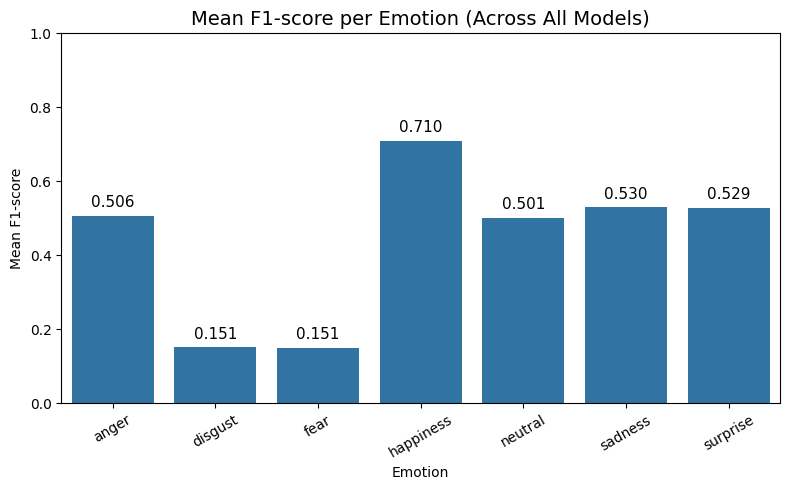

In [25]:
EMOTIONS = [
    col.replace("f1_", "")
    for col in df_discrete.columns
    if col.startswith("f1_")
]

df_f1_long = df_discrete.melt(
    id_vars=["model_name"],
    value_vars=[f"f1_{e}" for e in EMOTIONS],
    var_name="emotion",
    value_name="f1"
)

df_f1_long["emotion"] = df_f1_long["emotion"].str.replace("f1_", "")

df_emotion_mean = (
    df_f1_long
    .groupby("emotion")["f1"]
    .mean()
    .reset_index()
)

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))


ax = sns.barplot(
    data=df_emotion_mean,
    x="emotion",
    y="f1"
)

plt.title("Mean F1-score per Emotion (Across All Models)", fontsize=14)
plt.ylabel("Mean F1-score")
plt.xlabel("Emotion")
plt.ylim(0, 1)
plt.xticks(rotation=30)

# numbers on top of bars
for p in ax.patches:
    h = p.get_height()
    ax.annotate(f"{h:.3f}",
                (p.get_x() + p.get_width() / 2, h),
                ha="center", va="bottom",
                fontsize=11,
                xytext=(0, 4),
                textcoords="offset points")

plt.tight_layout()
plt.show()


In [8]:
df_f1_long

,model_name,emotion,f1
0,llava:13b,anger,0.475472
1,minicpm-v:8b,anger,0.374363
2,llava:7b,anger,0.488889
3,llava-phi3:3.8b,anger,0.333544
4,qwen3-vl:30b-a3b-instruct,anger,0.687694
...,...,...,...
86,qwen3-vl:32b-instruct,surprise,0.755416
87,llava-llama3:8b,surprise,0.370501
88,gemma3:12b-it-q4_K_M,surprise,0.459544
89,gemma3:4b-it-q4_K_M,surprise,0.302265


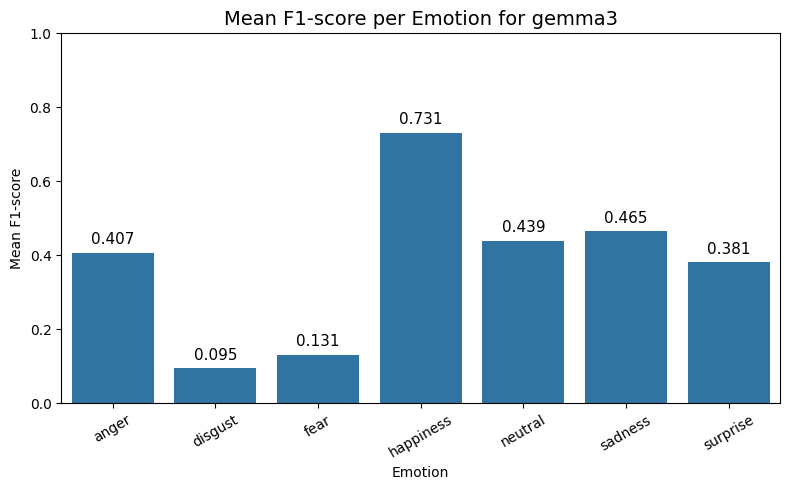

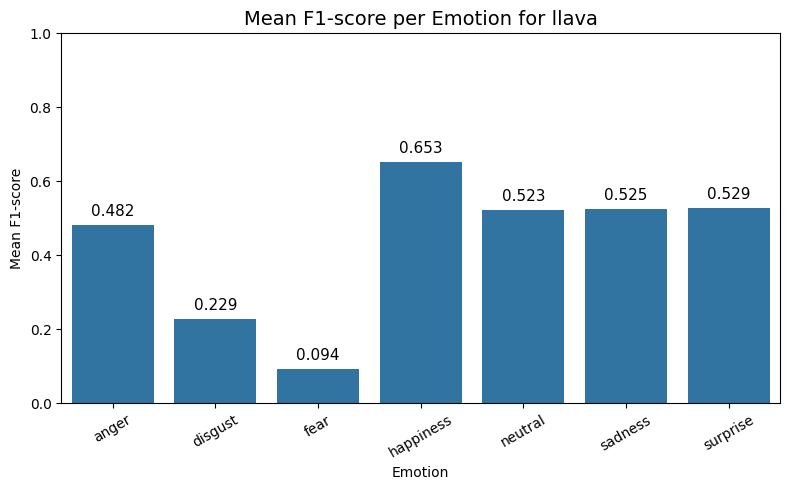

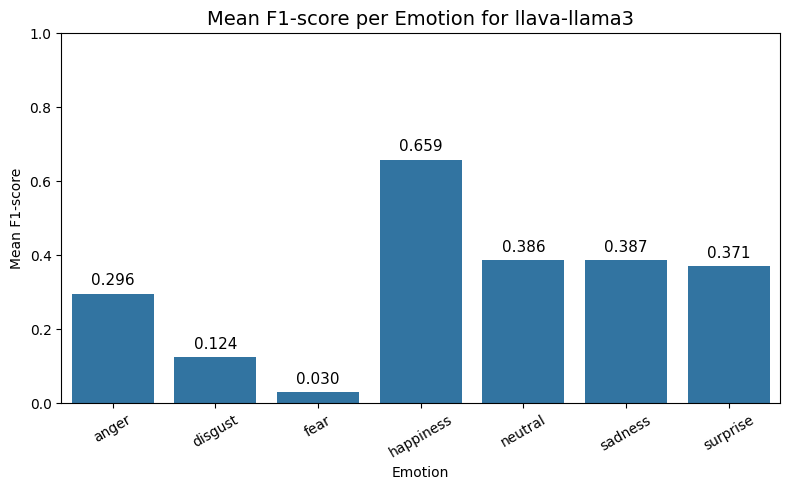

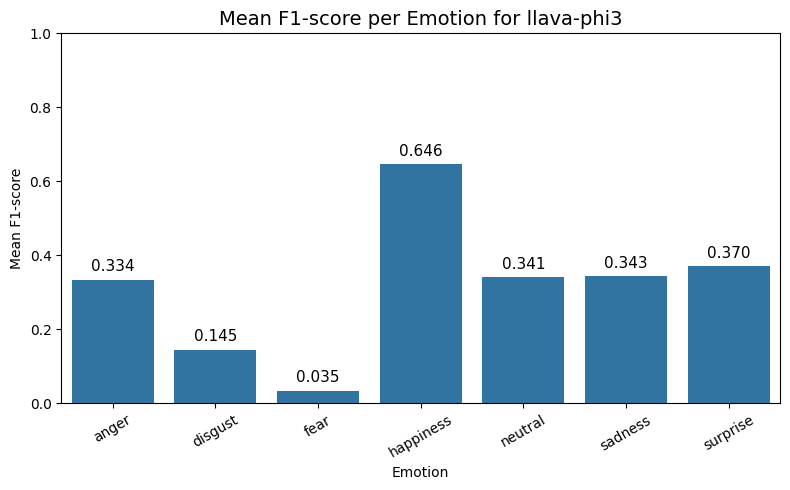

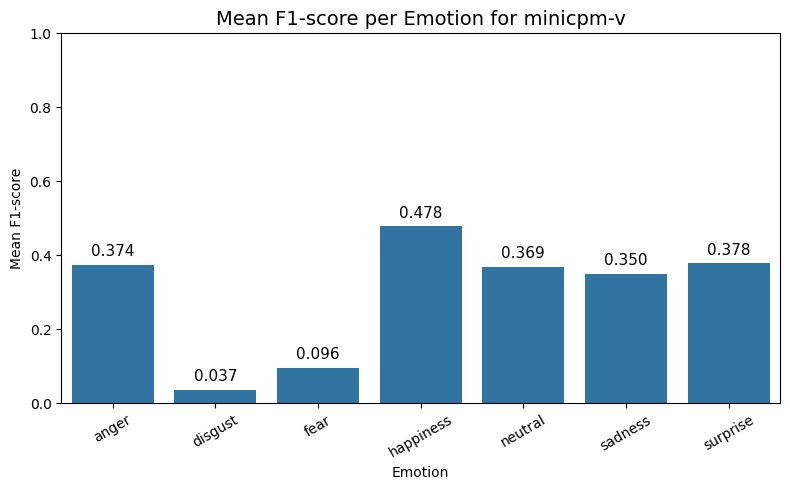

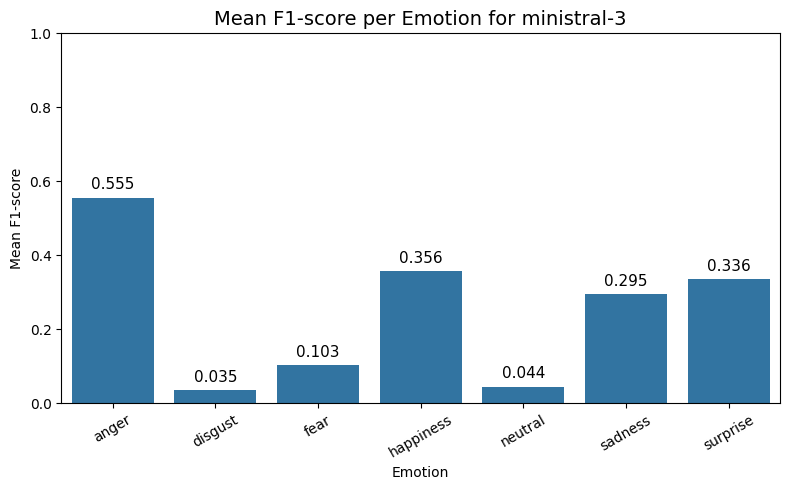

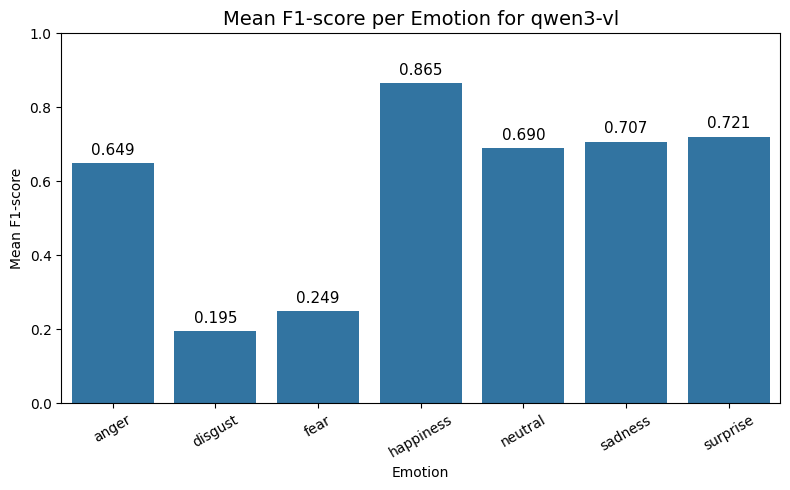

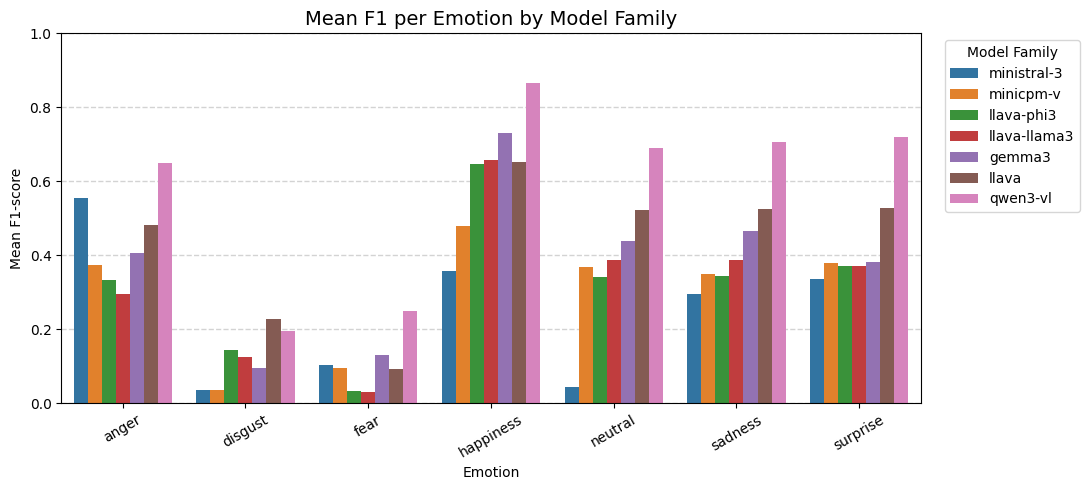

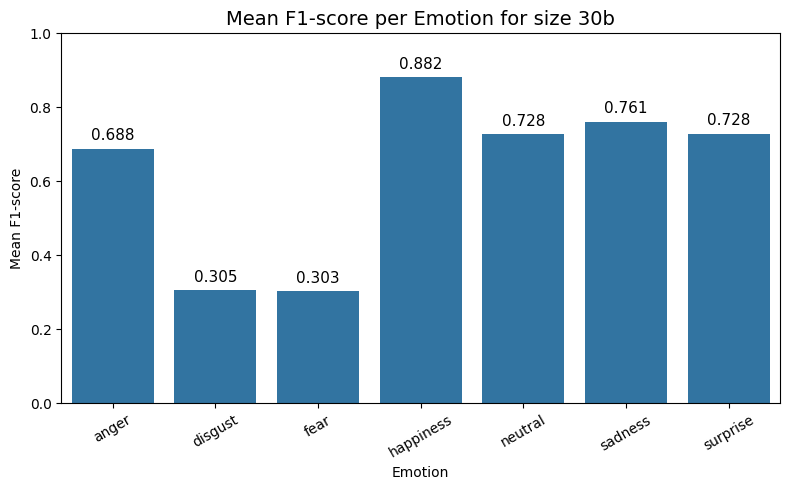

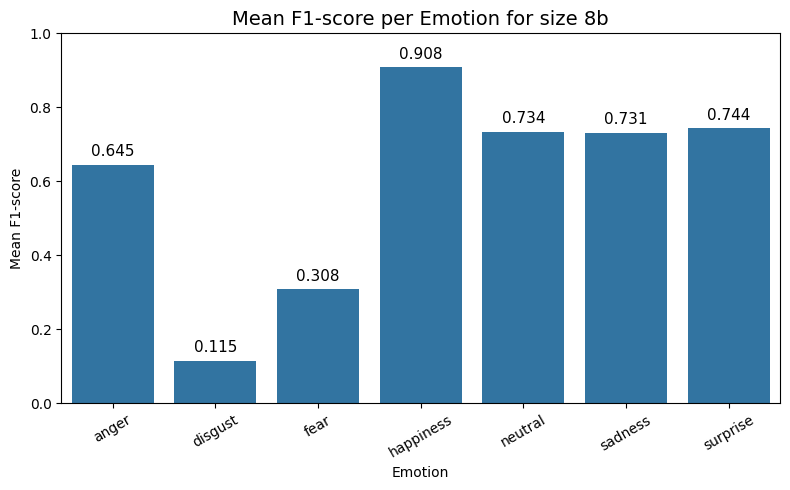

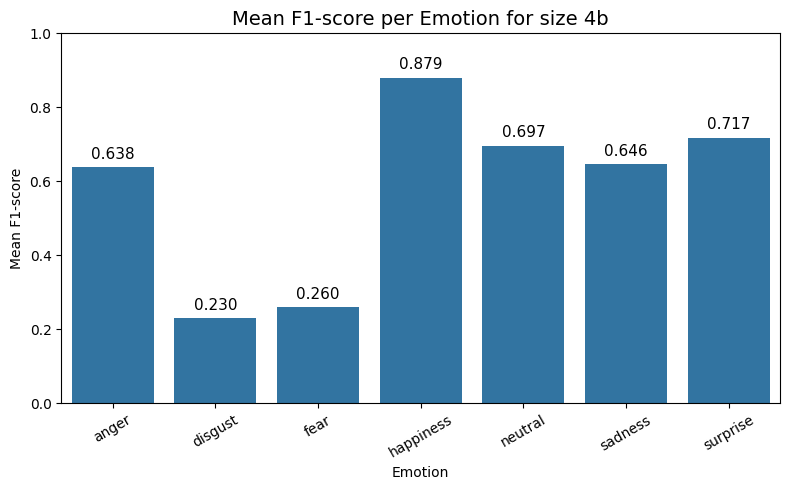

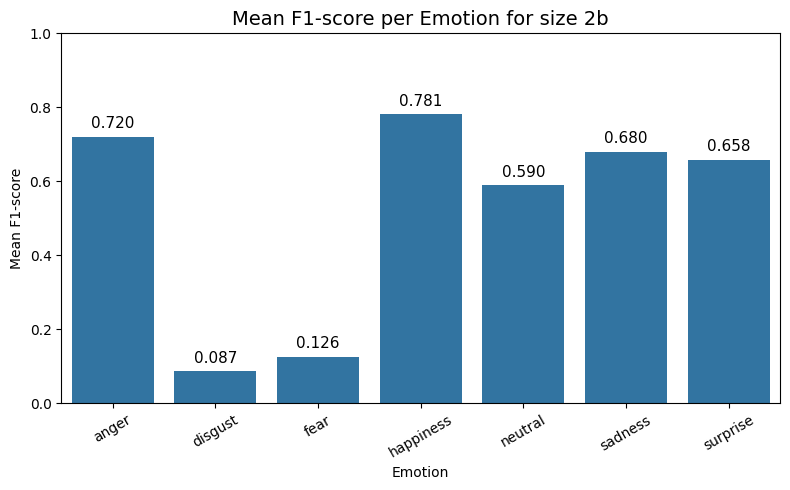

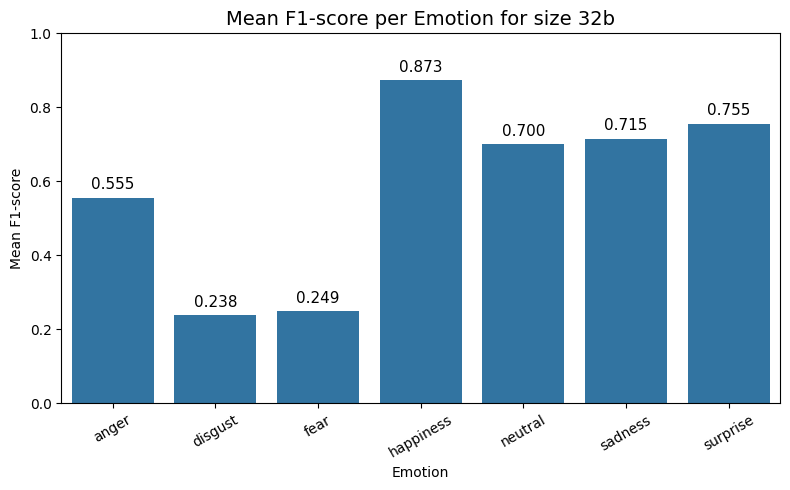

In [ ]:
### Model Family
import matplotlib.pyplot as plt
import seaborn as sns

df_f1_long['family'] = df_f1_long["model_name"].astype(str).str.strip().str.split(":", n=1).str[0]

df_f1_long
df_family_emotion_mean = (
    df_f1_long
    .groupby(["family","emotion"])["f1"]
    .mean()
    .reset_index()
)
df_family_emotion_mean


for family in df_family_emotion_mean['family'].unique():
    plt.figure(figsize=(8, 5))


    ax = sns.barplot(
        data=df_family_emotion_mean[df_family_emotion_mean['family'] == family],
        x="emotion",
        y="f1"
    )

    plt.title(f"Mean F1-score per Emotion for {family}", fontsize=14)
    plt.ylabel("Mean F1-score")
    plt.xlabel("Emotion")
    plt.ylim(0, 1)
    plt.xticks(rotation=30)

    # numbers on top of bars
    for p in ax.patches:
        h = p.get_height()
        ax.annotate(f"{h:.3f}",
                    (p.get_x() + p.get_width() / 2, h),
                    ha="center", va="bottom",
                    fontsize=11,
                    xytext=(0, 4),
                    textcoords="offset points")

    plt.tight_layout()
    plt.show()

df_emotion_family_mean = (
    df_f1_long
    .groupby(["family", "emotion"])["f1"]
    .mean()
    .reset_index()
)
family_order = (
    df_emotion_family_mean
    .groupby("family")["f1"]
    .mean()
    .sort_values()
    .index
    .tolist()
)

plt.figure(figsize=(11, 5))

ax = sns.barplot(
    data=df_emotion_family_mean,
    x="emotion",
    y="f1",
    hue="family",
    hue_order=family_order
)

ax.grid(True, which="major", axis="y", color="lightgray", linestyle="--", linewidth=1)
ax.set_axisbelow(True)  # deixa o grid atrás das barras
plt.title("Mean F1 per Emotion by Model Family", fontsize=14)
plt.ylabel("Mean F1-score")
plt.xlabel("Emotion")
plt.ylim(0, 1)
plt.xticks(rotation=30)
plt.legend(title="Model Family", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()


In [27]:
df_emotion_family_mean

,family,emotion,f1
0,gemma3,anger,0.407103
1,gemma3,disgust,0.095044
2,gemma3,fear,0.130971
3,gemma3,happiness,0.731047
4,gemma3,neutral,0.439464
5,gemma3,sadness,0.464867
6,gemma3,surprise,0.380904
7,llava,anger,0.482180
8,llava,disgust,0.228850
9,llava,fear,0.093937


## RQ3.2 — Do these difficulties vary across model sizes, output formats or prompting methods?

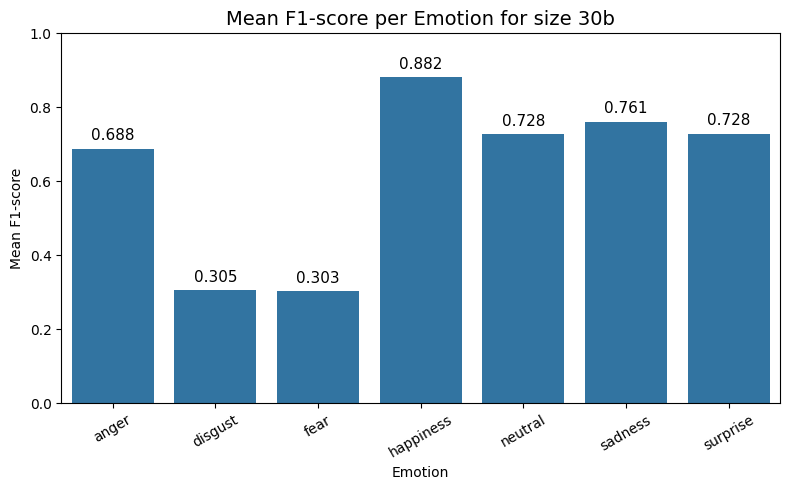

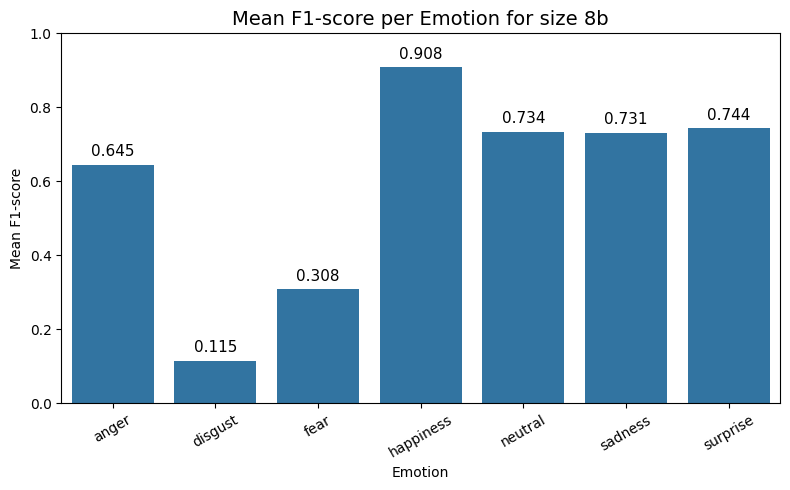

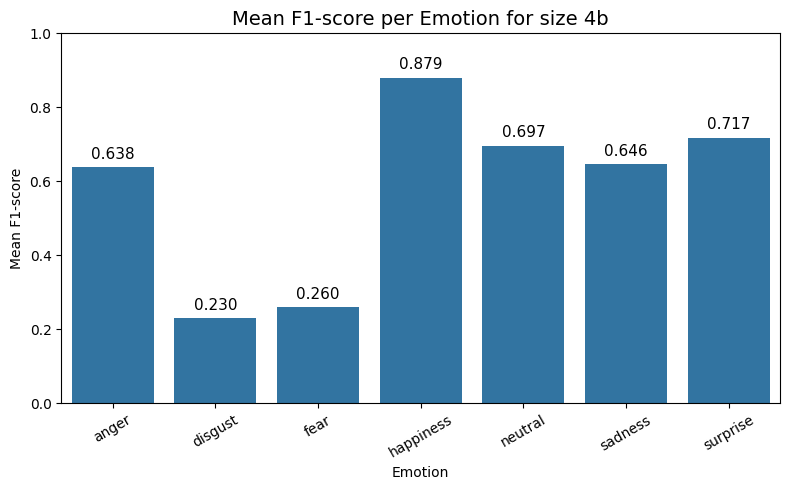

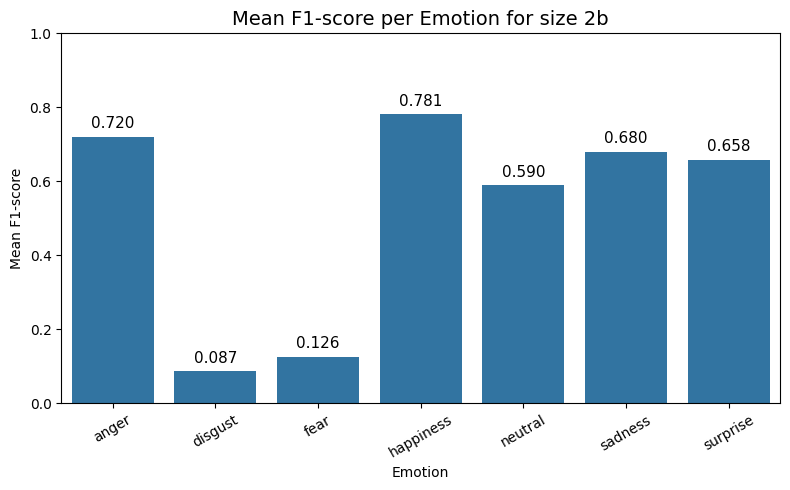

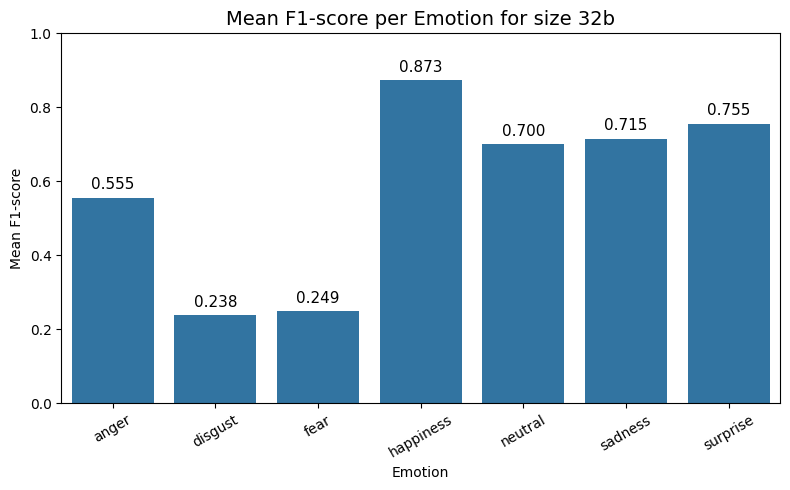

In [28]:


### Model Sizes
import matplotlib.pyplot as plt
import seaborn as sns

df_f1_long['family'] = df_f1_long["model_name"].astype(str).str.strip().str.split(":", n=1).str[0]

# df_f1_long
# df_family_emotion_mean = (
#     df_f1_long
#     .groupby(["family","emotion"])["f1"]
#     .mean()
#     .reset_index()
# )
# df_family_emotion_mean
df_f1_long = df_f1_long[df_f1_long['family']=="qwen3-vl"]
df_f1_long['size'] = df_f1_long["model_name"].astype(str).str.strip().str.split(":", n=1).str[1].str.split("-", n=1).str[0]
for size in df_f1_long['size'].unique():
    plt.figure(figsize=(8, 5))


    ax = sns.barplot(
        data=df_f1_long[df_f1_long['size'] == size],
        x="emotion",
        y="f1"
    )

    plt.title(f"Mean F1-score per Emotion for size {size}", fontsize=14)
    plt.ylabel("Mean F1-score")
    plt.xlabel("Emotion")
    plt.ylim(0, 1)
    plt.xticks(rotation=30)

    # numbers on top of bars
    for p in ax.patches:
        h = p.get_height()
        ax.annotate(f"{h:.3f}",
                    (p.get_x() + p.get_width() / 2, h),
                    ha="center", va="bottom",
                    fontsize=11,
                    xytext=(0, 4),
                    textcoords="offset points")

    plt.tight_layout()
    plt.show()

df_emotion_size_mean = (
    df_f1_long
    .groupby(["size", "emotion"])["f1"]
    .mean()
    .reset_index()
)

table_emotion_by_size = (
    df_emotion_size_mean
    .pivot(index="emotion", columns="size", values="f1")
    .sort_index()
)

table_emotion_by_size.round(3)

table_emotion_by_size['f1_mean'] = table_emotion_by_size.mean(axis=1)

In [22]:
table_emotion_by_size

size,2b,30b,32b,4b,8b,f1_mean
emotion,,,,,,
anger,0.719719,0.687694,0.554963,0.638031,0.645447,0.649171
disgust,0.087137,0.305356,0.238055,0.229532,0.114965,0.195009
fear,0.126214,0.302885,0.248588,0.260212,0.308134,0.249206
happiness,0.780710,0.881761,0.873440,0.879341,0.908274,0.864705
neutral,0.589689,0.727741,0.699771,0.696585,0.734439,0.689645
sadness,0.679726,0.760654,0.715054,0.646087,0.731265,0.706557
surprise,0.658436,0.727832,0.755416,0.717300,0.743791,0.720555


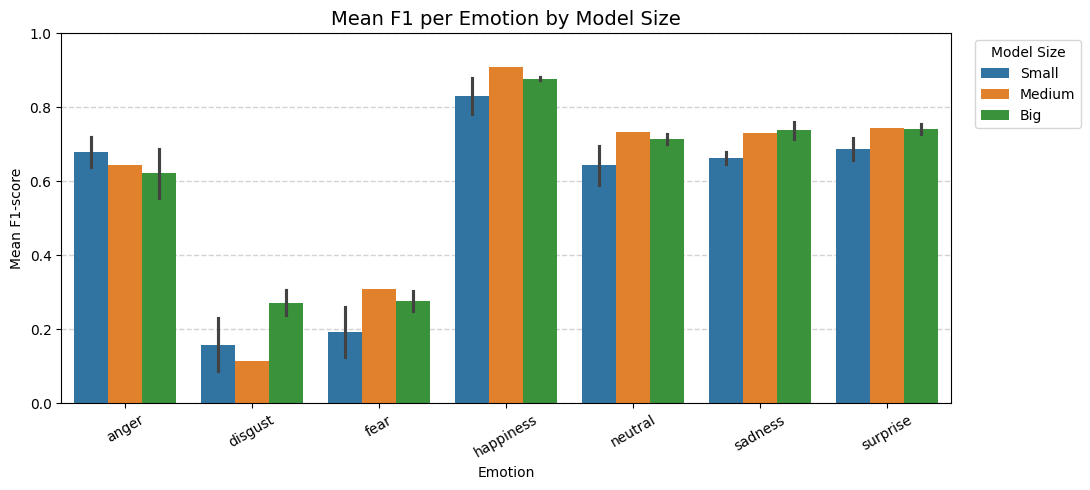

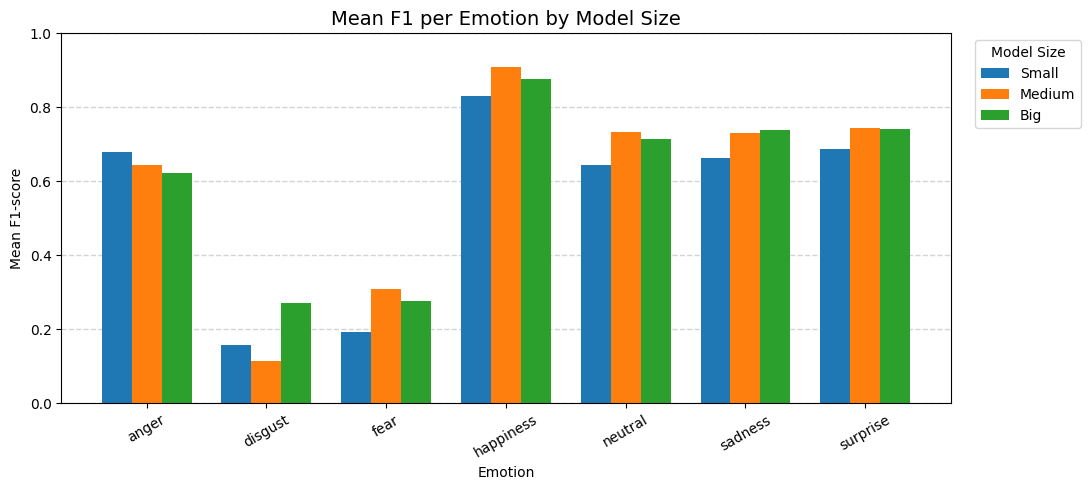

In [33]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# table_emotion_by_size: index=emotion, columns=['2b','4b','8b','30b','32b','f1_mean']
# (vou ignorar a coluna f1_mean no plot, já que queremos comparar os sizes)
df = table_emotion_by_size.reset_index()

# long format
df_long = df.melt(
    id_vars="emotion",
    value_vars=["2b", "4b", "8b", "30b", "32b"],
    var_name="size",
    value_name="f1"
)

# mapear size -> categoria
size_map = {"2b": "Small", "4b": "Small", "8b": "Medium", "30b": "Big", "32b": "Big"}
df_long["size_group"] = df_long["size"].map(size_map)

size_order = ["Small", "Medium", "Big"]

plt.figure(figsize=(11, 5))

ax = sns.barplot(
    data=df_long,
    x="emotion",
    y="f1",
    hue="size_group",
    hue_order=size_order
)

ax.grid(True, which="major", axis="y", color="lightgray", linestyle="--", linewidth=1)
ax.set_axisbelow(True)  # deixa o grid atrás das barras
plt.title("Mean F1 per Emotion by Model Size", fontsize=14)
plt.ylabel("Mean F1-score")
plt.xlabel("Emotion")
plt.ylim(0, 1)
plt.xticks(rotation=30)
plt.legend(title="Model Size", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# table_emotion_by_size: index=emotion, columns=['2b','4b','8b','30b','32b','f1_mean']
df = table_emotion_by_size.copy()

# (opcional) garantir que a ordem das emoções seja a mesma do seu outro gráfico
emotion_order = ["anger", "disgust", "fear", "happiness", "neutral", "sadness", "surprise"]
df = df.loc[emotion_order]

# agrupar sizes -> Small/Medium/Big
df_plot = pd.DataFrame({
    "Small": df[["2b", "4b"]].mean(axis=1),
    "Medium": df["8b"],
    "Big": df[["30b", "32b"]].mean(axis=1),
}, index=df.index)

# --- Matplotlib grouped bar chart ---
x = np.arange(len(df_plot.index))
groups = ["Small", "Medium", "Big"]
bar_w = 0.25

plt.figure(figsize=(11, 5))
ax = plt.gca()

for i, g in enumerate(groups):
    ax.bar(
        x + (i - 1) * bar_w,          # deslocamento: -w, 0, +w
        df_plot[g].values,
        width=bar_w,
        label=g,
        linewidth=0,                  # sem borda preta no topo
        edgecolor=None
    )

# grid cinza no eixo y
ax.grid(True, which="major", axis="y", color="lightgray", linestyle="--", linewidth=1)
ax.set_axisbelow(True)

ax.set_title("Mean F1 per Emotion by Model Size", fontsize=14)
ax.set_ylabel("Mean F1-score")
ax.set_xlabel("Emotion")
ax.set_ylim(0, 1)

ax.set_xticks(x)
ax.set_xticklabels(df_plot.index, rotation=30)

ax.legend(title="Model Size", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()


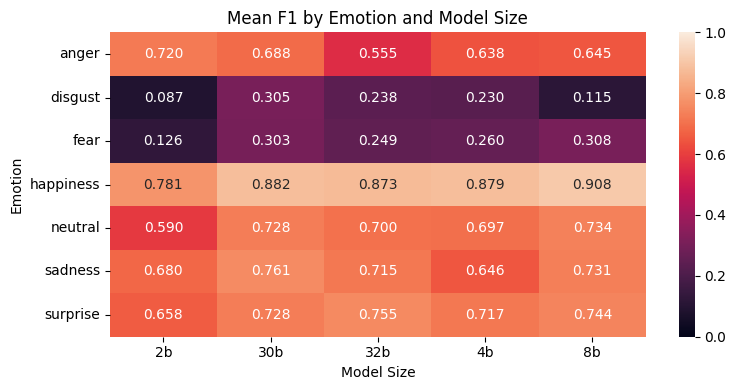

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 4))

sns.heatmap(
    table_emotion_by_size,
    annot=True,
    fmt=".3f",
    vmin=0,
    vmax=1
)

plt.title("Mean F1 by Emotion and Model Size")
plt.ylabel("Emotion")
plt.xlabel("Model Size")
plt.tight_layout()
plt.show()


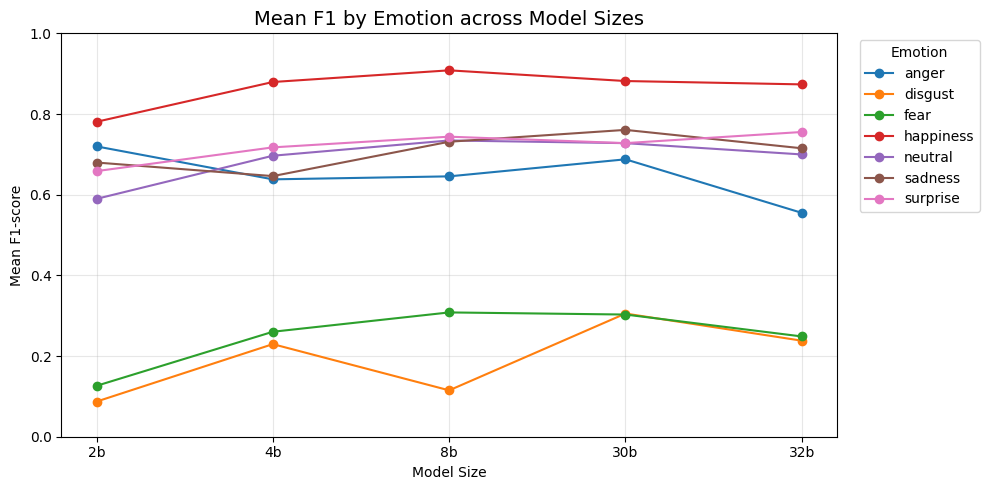

In [15]:
import matplotlib.pyplot as plt
import pandas as pd

# pivot to emotion x size
line_df = df_emotion_size_mean.pivot(index="emotion", columns="size", values="f1")

# ensure size order is numeric (2b, 4b, 8b, 30b, 32b)
size_order = sorted(line_df.columns, key=lambda s: int(str(s).replace("b", "")))
line_df = line_df[size_order]

plt.figure(figsize=(10, 5))

for emotion in line_df.index:
    plt.plot(size_order, line_df.loc[emotion].values, marker="o", label=emotion)

plt.title("Mean F1 by Emotion across Model Sizes", fontsize=14)
plt.xlabel("Model Size")
plt.ylabel("Mean F1-score")
plt.ylim(0, 1)
plt.grid(True, alpha=0.3)
plt.legend(title="Emotion", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()


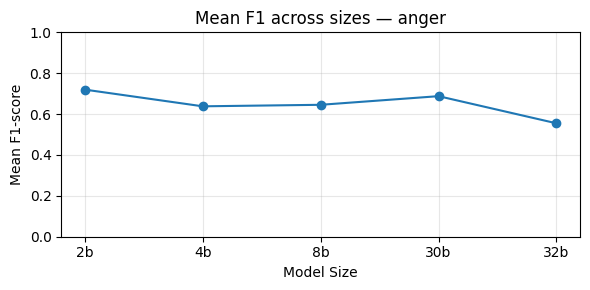

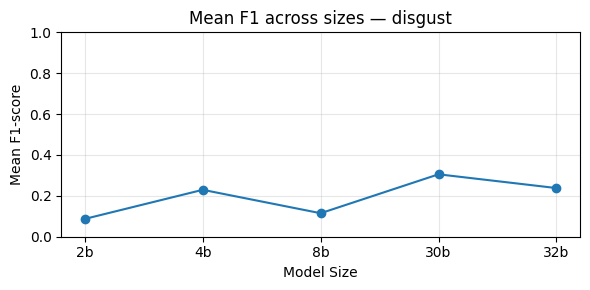

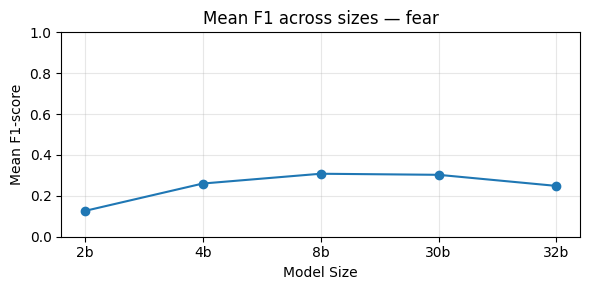

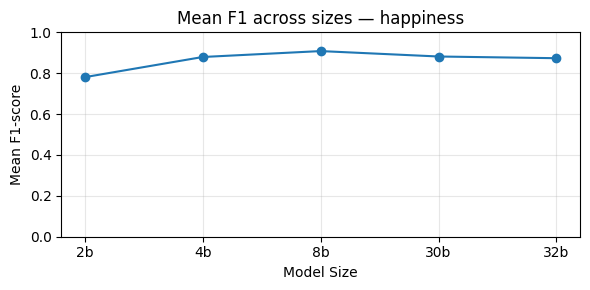

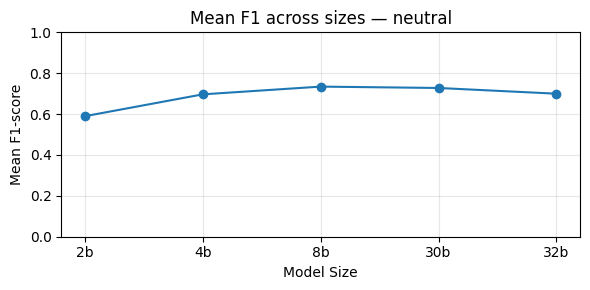

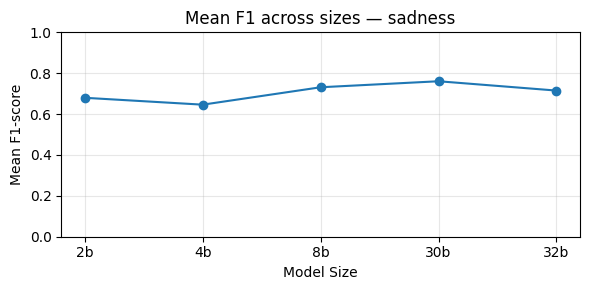

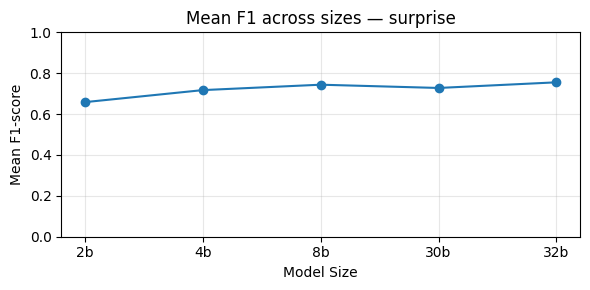

In [16]:
import matplotlib.pyplot as plt

line_df = df_emotion_size_mean.pivot(index="emotion", columns="size", values="f1")
size_order = sorted(line_df.columns, key=lambda s: int(str(s).replace("b", "")))
line_df = line_df[size_order]

for emotion in line_df.index:
    plt.figure(figsize=(6, 3))
    plt.plot(size_order, line_df.loc[emotion].values, marker="o")
    plt.title(f"Mean F1 across sizes — {emotion}", fontsize=12)
    plt.xlabel("Model Size")
    plt.ylabel("Mean F1-score")
    plt.ylim(0, 1)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


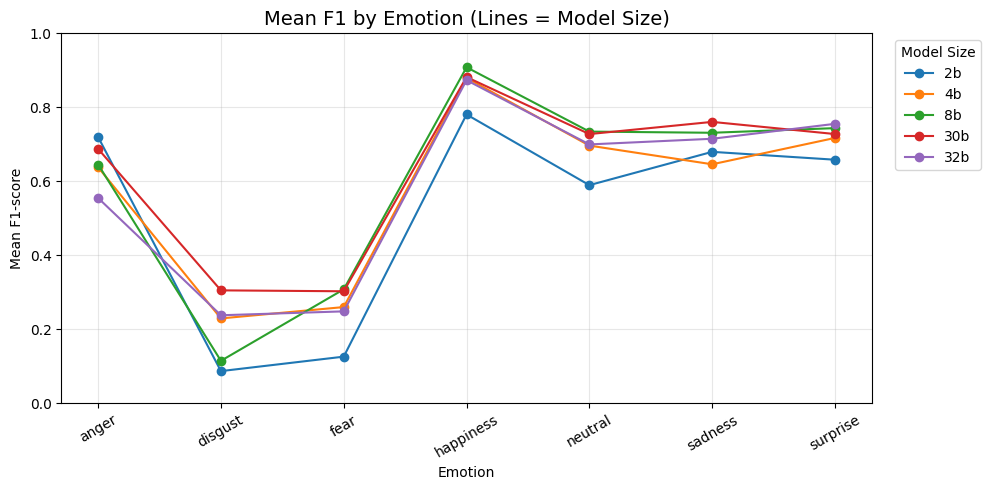

In [17]:
import matplotlib.pyplot as plt

# pivot: rows = size, cols = emotion
line_df = df_emotion_size_mean.pivot(index="size", columns="emotion", values="f1")

# ordenar sizes numericamente (2b, 4b, 8b, 30b, 32b)
size_order = sorted(line_df.index, key=lambda s: int(str(s).replace("b", "")))
line_df = line_df.loc[size_order]

# (opcional) ordenar emoções numa ordem fixa (ajuste se quiser)
emotion_order = ["anger", "disgust", "fear", "happiness", "neutral", "sadness", "surprise"]
emotion_order = [e for e in emotion_order if e in line_df.columns]  # safety
line_df = line_df[emotion_order]

plt.figure(figsize=(10, 5))

x = range(len(emotion_order))

for size in line_df.index:
    plt.plot(x, line_df.loc[size].values, marker="o", label=size)

plt.title("Mean F1 by Emotion (Lines = Model Size)", fontsize=14)
plt.xlabel("Emotion")
plt.ylabel("Mean F1-score")
plt.ylim(0, 1)
plt.xticks(x, emotion_order, rotation=30)
plt.grid(True, alpha=0.3)
plt.legend(title="Model Size", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()


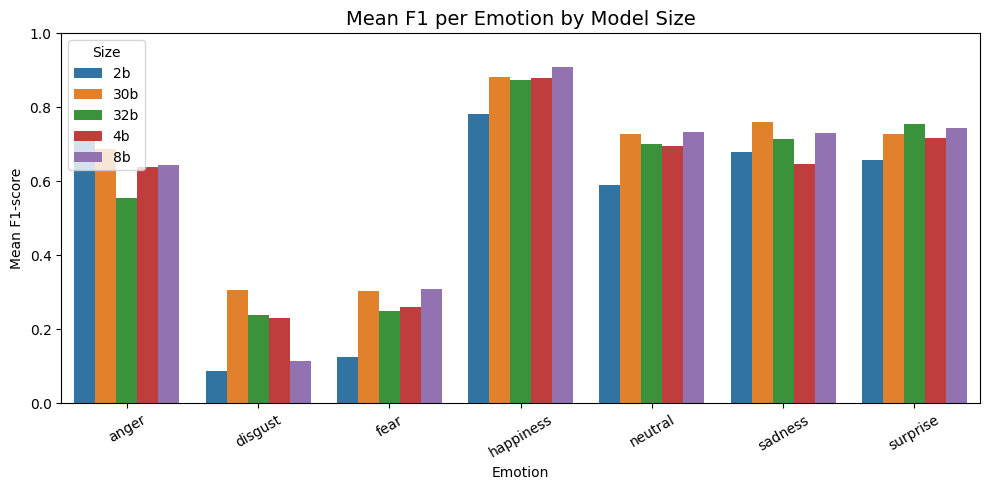

In [18]:
plt.figure(figsize=(10, 5))

ax = sns.barplot(
    data=df_emotion_size_mean,
    x="emotion",
    y="f1",
    hue="size"
)

plt.title("Mean F1 per Emotion by Model Size", fontsize=14)
plt.ylabel("Mean F1-score")
plt.xlabel("Emotion")
plt.ylim(0, 1)
plt.xticks(rotation=30)
plt.legend(title="Size")


plt.tight_layout()
plt.show()


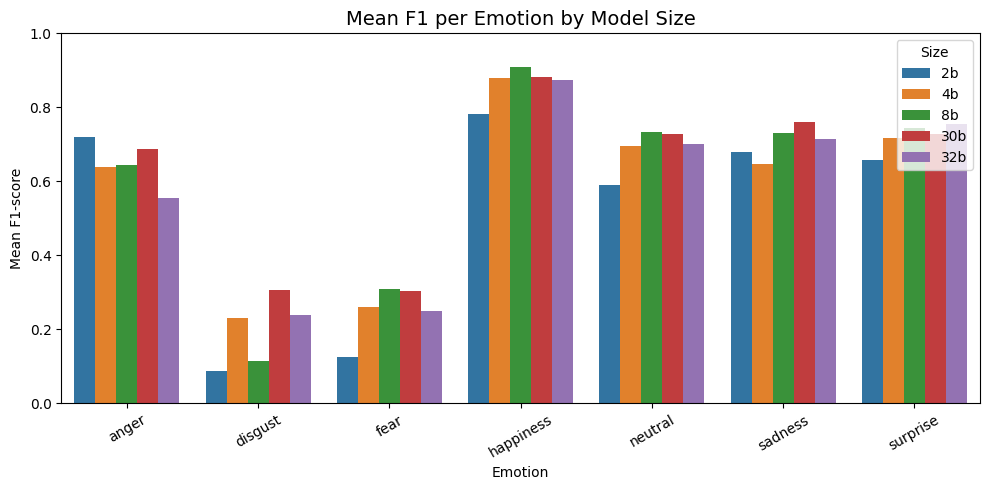

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

size_order = sorted(
    df_emotion_size_mean["size"].unique(),
    key=lambda s: int(str(s).replace("b", ""))
)

plt.figure(figsize=(10, 5))

ax = sns.barplot(
    data=df_emotion_size_mean,
    x="emotion",
    y="f1",
    hue="size",
    hue_order=size_order
)

plt.title("Mean F1 per Emotion by Model Size", fontsize=14)
plt.ylabel("Mean F1-score")
plt.xlabel("Emotion")
plt.ylim(0, 1)
plt.xticks(rotation=30)
plt.legend(title="Size")

plt.tight_layout()
plt.show()


### RQ3.3 — Do VLLMs exhibit systematic valence bias, such as overpredicting positive emotions?

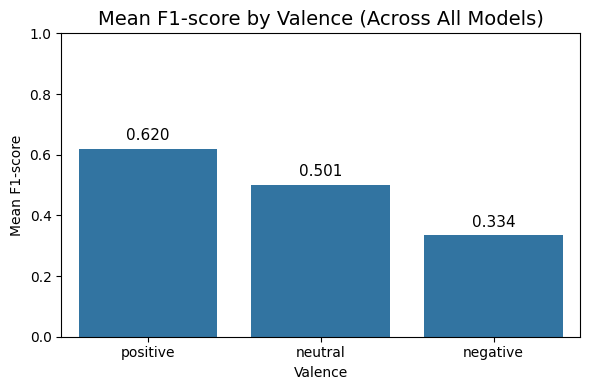

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1) lista de emoções pelo prefixo f1_
EMOTIONS = [c.replace("f1_", "") for c in df_discrete.columns if c.startswith("f1_")]

# 2) long format
df_f1_long = df_discrete.melt(
    id_vars=["model_name"],
    value_vars=[f"f1_{e}" for e in EMOTIONS],
    var_name="emotion",
    value_name="f1"
)
df_f1_long["emotion"] = df_f1_long["emotion"].str.replace("f1_", "")

# 3) mapear valência
POSITIVE = {"happiness", "surprise"}
NEGATIVE = {"anger", "disgust", "fear", "sadness"}

def map_valence(e):
    if e in POSITIVE:
        return "positive"
    if e in NEGATIVE:
        return "negative"
    return "other"   # neutral (ou qualquer outra)

df_f1_long["valence"] = df_f1_long["emotion"].apply(map_valence)

df_val = df_f1_long.copy()
df_val["valence"] = df_val["valence"].replace({"other": "neutral"})

# 5) média "justa": primeiro por (model, valence), depois por valence
df_model_val_mean = (
    df_val
    .groupby(["model_name", "valence"])["f1"]
    .mean()
    .reset_index()
)

df_valence_mean = (
    df_model_val_mean
    .groupby("valence")["f1"]
    .mean()
    .reset_index()
    .sort_values("f1", ascending=False)
)

# 6) plot
plt.figure(figsize=(6, 4))
ax = sns.barplot(data=df_valence_mean, x="valence", y="f1")

plt.title("Mean F1-score by Valence (Across All Models)", fontsize=14)
plt.ylabel("Mean F1-score")
plt.xlabel("Valence")
plt.ylim(0, 1)

# números no topo
for p in ax.patches:
    h = p.get_height()
    ax.annotate(
        f"{h:.3f}",
        (p.get_x() + p.get_width()/2, h),
        ha="center", va="bottom",
        fontsize=11,
        xytext=(0, 4),
        textcoords="offset points"
    )

plt.tight_layout()
plt.show()
